In [1]:
import os
import math
import imblearn
import logging
import warnings
import statistics
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score , accuracy_score , precision_score, recall_score ,confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numpy import genfromtxt
from mpl_toolkits.mplot3d import Axes3D
from imblearn.combine import SMOTEENN
%matplotlib inline




from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

In [2]:
#read csv file and store it in df

df = pd.read_csv('Epileptic Seizure Recognition.csv')


In [3]:
#return first 5 rows
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
#obtain summary of dataset
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [5]:
#obtain shape of dataset
df.shape

(11500, 180)

In [6]:
#obtain data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [7]:
#object data type
df.select_dtypes('object')


,Unnamed
0,X21.V1.791
1,X15.V1.924
2,X8.V1.1
3,X16.V1.60
4,X20.V1.54
...,...
11495,X22.V1.114
11496,X19.V1.354
11497,X8.V1.28
11498,X10.V1.932


In [8]:

df.describe(include=object)

,Unnamed
count,11500
unique,11500
top,X21.V1.791
freq,1


In [9]:
#check for any null values and drop if any
df.isnull().values.any()
df.dropna()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


In [10]:
#copy df into another variable df2 and drop unnamed column and y
df2 = df.copy()
df2.drop(['Unnamed','y'],axis=1,inplace=True)

In [11]:
#retrieve first five rows 
df2.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73


In [12]:
df['y'].value_counts()
#observation that output is equally distributed

4    2300
1    2300
5    2300
2    2300
3    2300
Name: y, dtype: int64

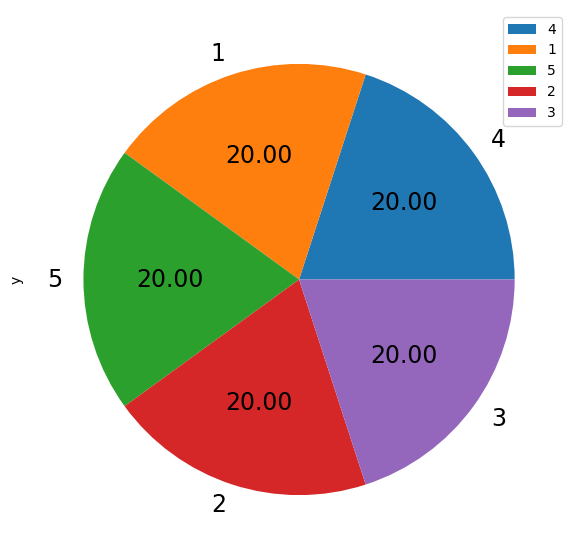

In [13]:
#visualizing the only categorical column present in the dataset.
values = df['y'].value_counts()
plt.figure(figsize=(7,7))
values.plot(kind='pie',fontsize=17, autopct='%.2f')
plt.legend(loc="best")
plt.show()
#it means all the categorical values in our dataset contains the equal amoung of balance.

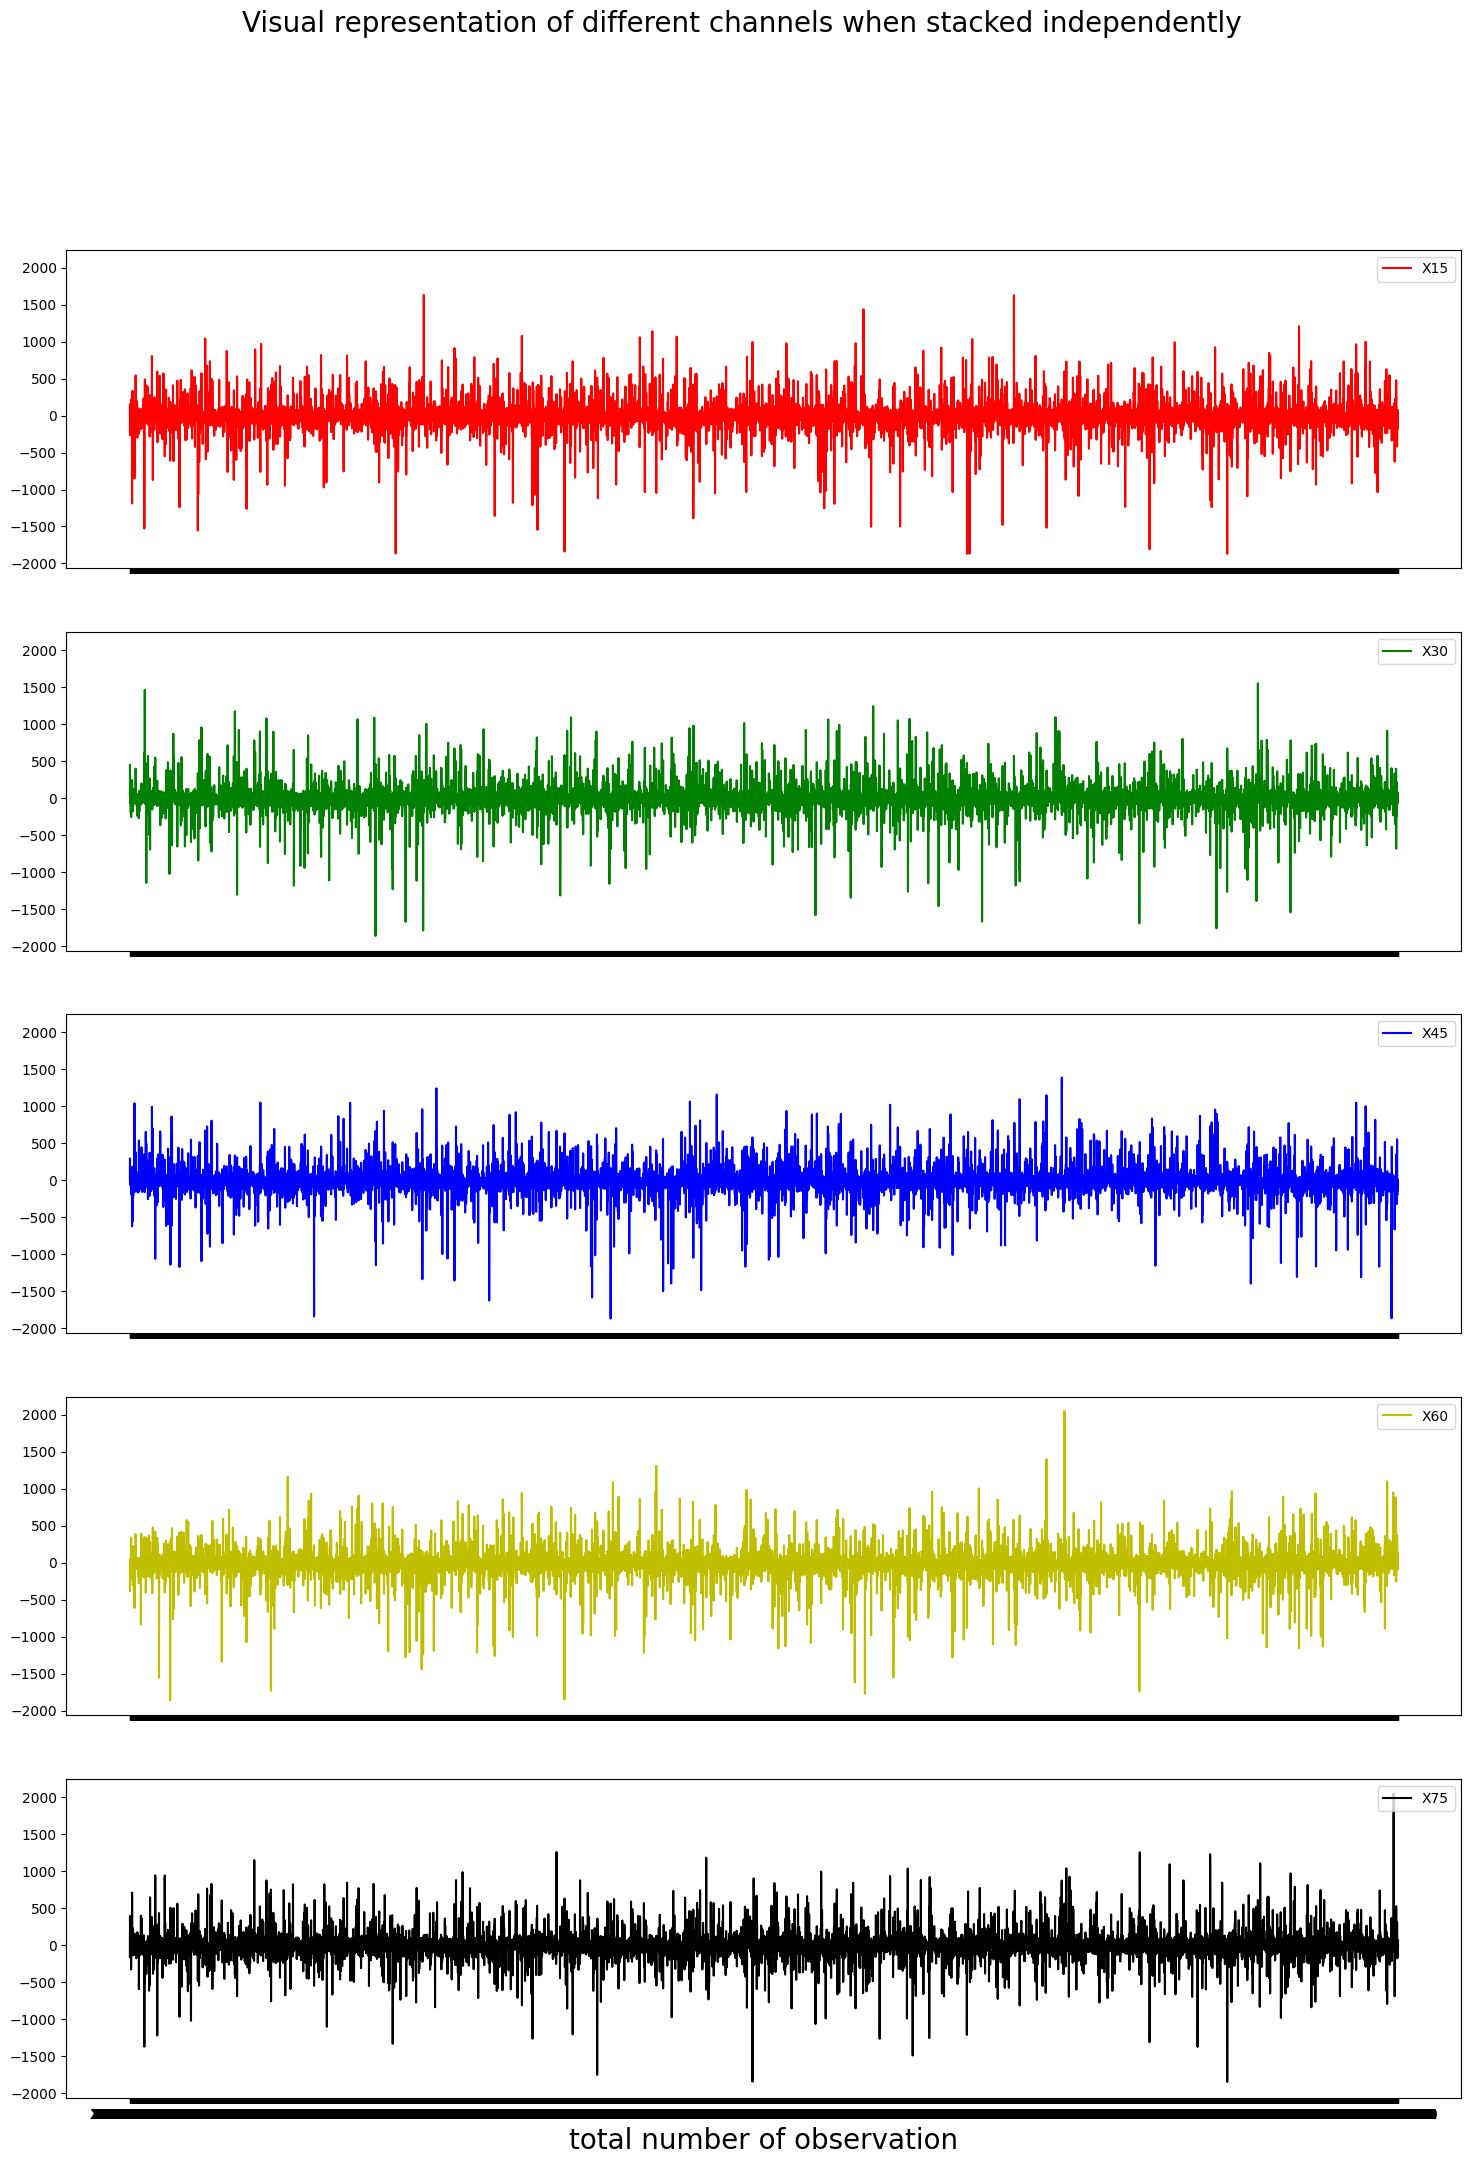

In [14]:
# plot these features in the same graph with stack plot
fig, axs = plt.subplots(5, sharex=True, sharey=True)
fig.set_size_inches(18, 24)
labels = ["X15","X30","X45","X60","X75"]
colors = ["r","g","b",'y',"k"]
fig.suptitle('Visual representation of different channels when stacked independently', fontsize = 20)
# loop over axes
for i,ax in enumerate(axs):
  axs[i].plot(df.iloc[:,0],df[labels[i]],color=colors[i],label=labels[i])
  axs[i].legend(loc="upper right")

plt.xlabel('total number of observation', fontsize = 20)
plt.show()

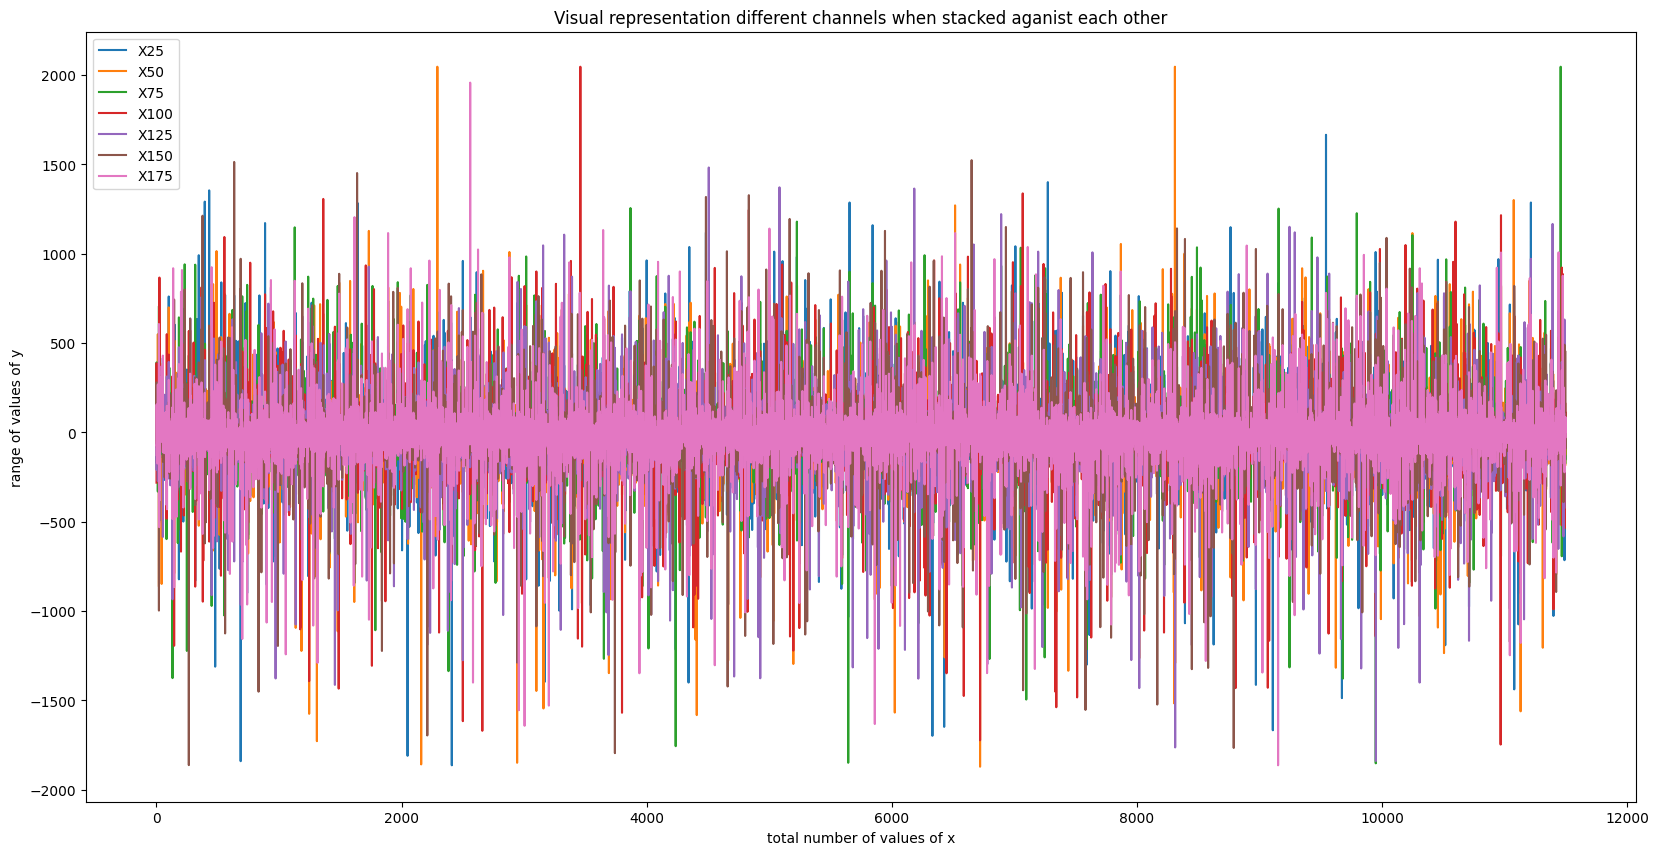

In [15]:
#plt.figure(figsize=(10,10))
#this can help of provide us the general idea of how the waves are behaving 
#fig, axs = plt.subplots(1, sharex=True, sharey=True)
plt.rcParams["figure.figsize"] = (20, 10)
df.loc[:,::25].plot()
plt.title("Visual representation different channels when stacked aganist each other")
plt.xlabel("total number of values of x")
plt.ylabel("range of values of y")
plt.show()

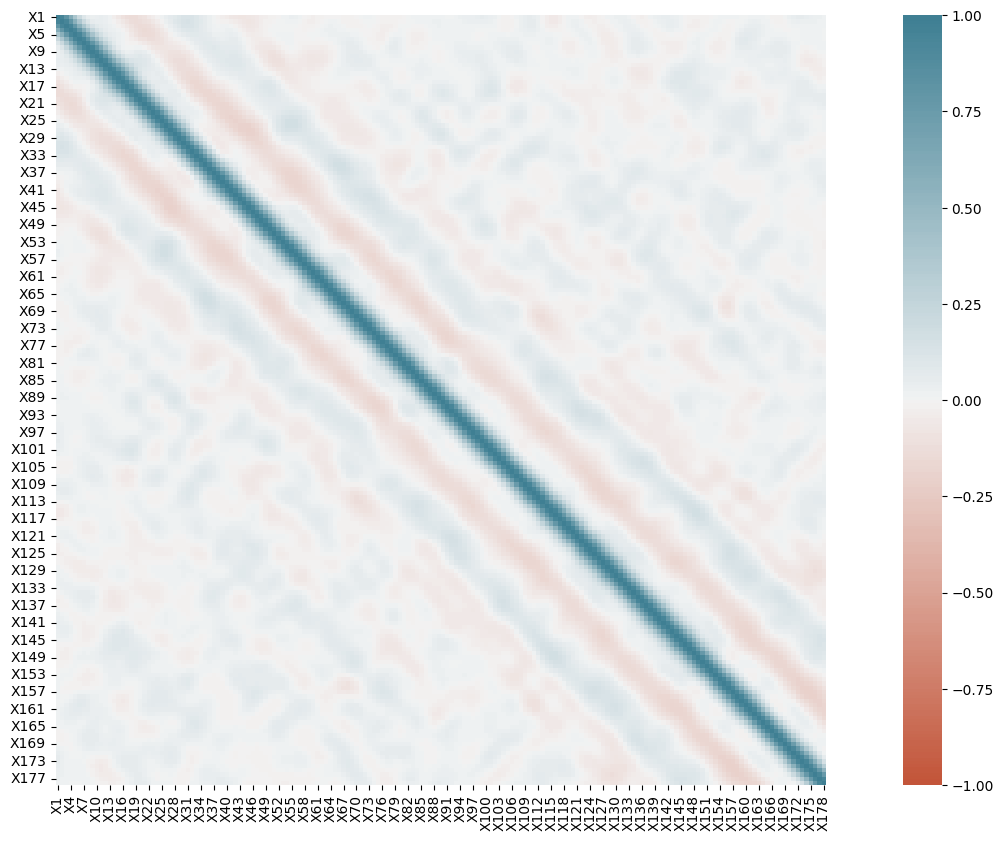

In [16]:
# Correlation Matrix
corr = df2.corr()
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)

In [17]:
#drop unnamed column in df and store a copy in df3

df3 = df.drop(["Unnamed"],axis=1).copy()

In [18]:
df3["Output"]= df3.y == 0
df3.y.value_counts()
#uniformly distributed values for each output type

4    2300
1    2300
5    2300
2    2300
3    2300
Name: y, dtype: int64

In [19]:
df3['y'] = df3['y'].replace([2,3,4,5],0)
#because 2,3,4,5 are not identifying factors for seizure we neglect them

In [20]:
df3.y.value_counts() 
#we can see there is a mojor class imbalance problem in our dataset

0    9200
1    2300
Name: y, dtype: int64

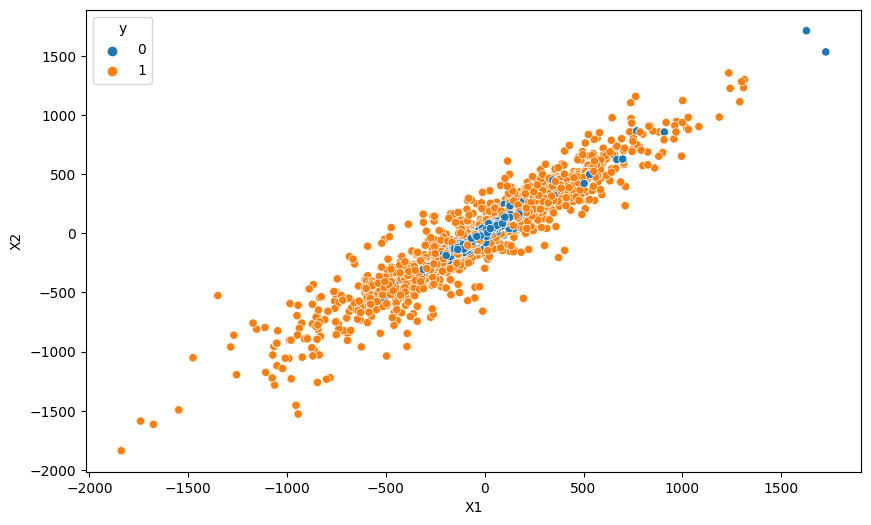

In [21]:
plt.figure(figsize=(10,6),dpi=100)
sns.despine(left=True)
sns.scatterplot(x='X1', y='X2', hue = 'y', data=df3)
plt.show()
#we can see the clear class imbalance problem present here

In [22]:
df3.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X171,X172,X173,X174,X175,X176,X177,X178,y,Output
0,135,190,229,223,192,125,55,-9,-33,-38,...,-15,-31,-77,-103,-127,-116,-83,-51,0,False
1,386,382,356,331,320,315,307,272,244,232,...,150,146,152,157,156,154,143,129,1,False
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,64,48,19,-12,-30,-35,-35,-36,0,False
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-81,-80,-77,-85,-77,-72,-69,-65,0,False
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,2,-12,-32,-41,-65,-83,-89,-73,0,False


In [23]:
df3.y.value_counts()
#only 2300 outputs considered to be actual 

0    9200
1    2300
Name: y, dtype: int64

In [24]:
X  = df3.drop(['Output','y'], axis=1)
y = df3['y']

In [25]:
counter = Counter(y)
#finding out the 
print('Before',counter)
# oversampling the train dataset using SMOTE + ENN
smenn = SMOTEENN()
X_train1, y_train1 = smenn.fit_resample(X, y)

counter = Counter(y_train1)
print('After',counter)

Before Counter({0: 9200, 1: 2300})
After Counter({0: 9070, 1: 9046})


In [26]:
#so we will start with dividing it into two parts/because with this method we cannot divide it into three parts
X_train, X_test, y_train, y_test = train_test_split(X_train1,y_train1,test_size=0.4,random_state=42)

#now we will be dividing it into further to get the validation set

X_val, X_test, y_val, y_test = train_test_split(X_test,y_test,test_size=0.5,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#now we will going to scale the dataset
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [28]:
print("The shape of the training set is :{}".format(X_train.shape))
print("The shape of the testing set is :{}".format(X_test.shape))
print("The shape of the validation set is :{}".format(X_val.shape))

The shape of the training set is :(10869, 178)
The shape of the testing set is :(3624, 178)
The shape of the validation set is :(3623, 178)


In [29]:
#saving the dataset into a csv file
df_train = pd.DataFrame(X_train)
df_train['y'] = y_train.values
df_train.to_csv('train.csv', index=False)
df_val = pd.DataFrame(X_val)
df_val['y'] = y_val.values
df_val.to_csv('val.csv', index=False)
df_test = pd.DataFrame(X_test)
df_test['y'] = y_test.values
df_test.to_csv('test.csv', index=False)